# Kilonova transformer — evaluación

Evaluación del modelo entrenado (OpenUniverse, binario `{other, KN}`) sobre el split de **test**:

1. **Accuracy / loss vs epoch** — desde los logs CSV de la corrida.
2. **Precision / recall vs threshold** — un subplot por régimen {1, 2, 3 épocas}.
3. **Matriz de confusión** — un subplot por régimen {1, 2, 3 épocas}.
4. **Threshold 0.2** — contaminantes por clase, por régimen.

**Todo se evalúa SIN redshift** (`force_redshift=False`), la métrica honesta: KN y contaminantes
están casi disjuntos en z, así que evaluar *con* z infla el accuracy (artefacto poblacional).
Es coherente con la selección de modelo, que usa `val_acc_noz`.

In [1]:
import glob, os, re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

# modelo a evaluar: la 'soup' (promedio de los top-5 checkpoints) es el modelo final.
CHECKPOINT = 'checkpoints/kilonova_transformer-soup.ckpt'
assert os.path.exists(CHECKPOINT), CHECKPOINT
print('checkpoint:', CHECKPOINT)

# salida de figuras (una PDF por plot) + paleta consistente
PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)
C_PRECISION = '#3A86FF'   # azul vivo
C_RECALL    = '#2EC4B6'   # teal
C_OTHER     = '#8D99AE'   # gris azulado (contaminantes de fondo)
C_KN        = '#FB5607'   # naranja intenso (la clase de interés resalta)
C_CONTAM    = '#8338EC'   # violeta (barras de contaminación)

def savefig(fig, name):
    path = os.path.join(PLOTS_DIR, name)
    fig.savefig(path, bbox_inches='tight')
    print('saved', path)

device: cuda
checkpoint: checkpoints/kilonova_transformer-soup.ckpt


## 1. Accuracy / loss vs epoch

Se lee el `metrics.csv` de la última corrida en `lightning_logs/`. Las filas de train y de
validación se loguean por separado, así que agrupamos por epoch (el `mean` ignora los NaN).

metrics: lightning_logs/version_1/metrics.csv


saved plots/01_loss_accuracy.pdf


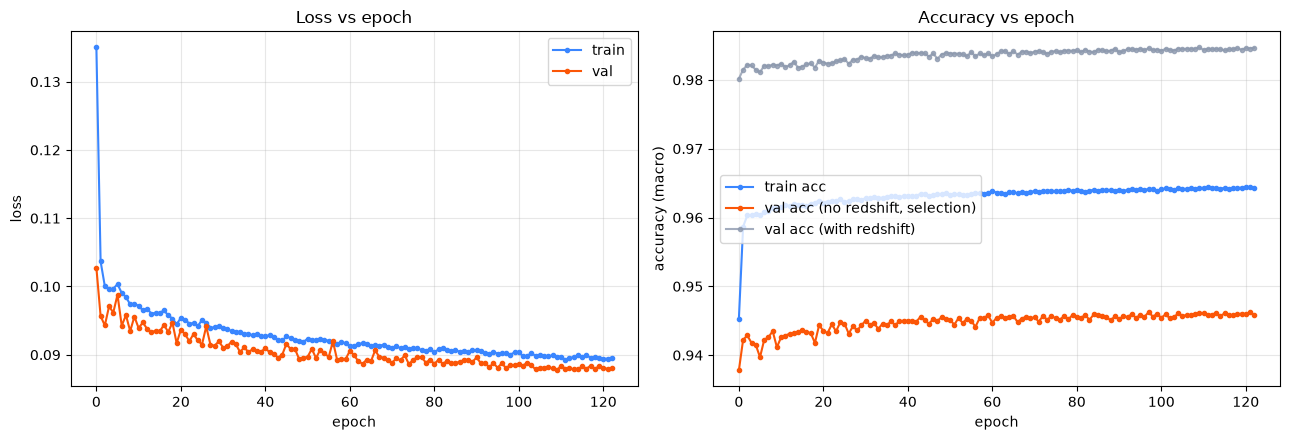

In [2]:
versions = glob.glob('lightning_logs/version_*/metrics.csv')
latest = max(versions, key=lambda p: int(re.search(r'version_(\d+)', p).group(1)))
print('metrics:', latest)

df = pd.read_csv(latest)
curve = df.groupby('epoch').mean(numeric_only=True)  # colapsa filas train/val por epoch

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 4.5))

ax_loss.plot(curve.index, curve['train_loss'], label='train', marker='.', color=C_PRECISION)
ax_loss.plot(curve.index, curve['val_loss'], label='val', marker='.', color=C_KN)
ax_loss.set_xlabel('epoch'); ax_loss.set_ylabel('loss')
ax_loss.set_title('Loss vs epoch'); ax_loss.legend(); ax_loss.grid(alpha=0.3)

ax_acc.plot(curve.index, curve['train_acc'], label='train acc', marker='.', color=C_PRECISION)
ax_acc.plot(curve.index, curve['val_acc_noz'], label='val acc (no redshift, selection)', marker='.', color=C_KN)
if 'val_acc_z' in curve:
    ax_acc.plot(curve.index, curve['val_acc_z'], label='val acc (with redshift)', marker='.',
                color=C_OTHER, alpha=0.8)
ax_acc.set_xlabel('epoch'); ax_acc.set_ylabel('accuracy (macro)')
ax_acc.set_title('Accuracy vs epoch'); ax_acc.legend(); ax_acc.grid(alpha=0.3)

plt.tight_layout(); savefig(fig, '01_loss_accuracy.pdf'); plt.show()

## Cargar datos y el modelo

`build_dataloaders` ajusta la normalización de magnitudes (sobre el split de train) y fija los
globales del módulo que usarán los datasets. La primera corrida arma el cache de tokens; luego
es instantáneo.

In [3]:
from openuniverse_data import build_dataloaders, GROUP_ORDER
from train_lightning import LitKilonova, MODEL_INPUT_KEYS

def first_existing(candidates, default):
    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate
    return default


# Resolved against the notebook's working directory (training/), the same idiom as
# attention_visualization.ipynb, so this travels between machines. The absolute path it replaces
# only existed on the Linux training box.
DATA_DIR = first_existing(['data/openuniverse', '../data/openuniverse'], '../data/openuniverse')
data = build_dataloaders(
    kn_deep=f'{DATA_DIR}/kn_windows_deep.parquet',
    kn_wide=f'{DATA_DIR}/kn_windows_wide.parquet',
    contaminant_deep=f'{DATA_DIR}/early_windows_deep.parquet',
    contaminant_wide=f'{DATA_DIR}/early_windows_wide.parquet',
    batch_size=512, num_workers=8,
    cache_path=f'{DATA_DIR}/openuniverse_tokens.npz',
)
print('GROUP_ORDER:', GROUP_ORDER, '  (positivo = KN = clase 1)')
print('split:', data['split_sizes'])
print('balance test:', data['class_balance']['test'])

# class_weights solo afecta la loss, no la inferencia -> unos.
model = LitKilonova.load_from_checkpoint(CHECKPOINT, class_weights=torch.ones(len(GROUP_ORDER)))
model = model.to(device).eval()
print('parametros:', sum(p.numel() for p in model.model.parameters()))

loading cached tokens from /home/nicolas/nico/git/Kilonova/data/openuniverse/openuniverse_tokens.npz


GROUP_ORDER: ['other', 'KN']   (positivo = KN = clase 1)
split: {'train': 2693804, 'validation': 151915, 'test': 153661}
balance test: {'other': 79885, 'KN': 73776}


parametros: 2674225


## Loaders de test por régimen {1, 2, 3 épocas}, SIN redshift

Reconstruimos el split de **test** (determinista: mismos `fractions`/`seed` que `build_dataloaders`)
y armamos un loader por cada régimen de épocas. `force_redshift=False` fuerza el régimen **sin z**
en todos.

In [4]:
from torch.utils.data import DataLoader
from openuniverse_data import (_load_or_build, _leakage_aware_split,
    OpenUniverseWindowDataset, collate_token_windows, GROUP_TO_LABEL)

# cache ya existe -> las rutas de fuentes no se usan; el split es determinista (seed 42).
big, meta = _load_or_build(f'{DATA_DIR}/openuniverse_tokens.npz', None, None, None, None, verbose=False)
label_by_index = np.where(meta['is_kn'], GROUP_TO_LABEL['KN'], GROUP_TO_LABEL['other'])
_, _, test_index = _leakage_aware_split(meta, (0.90, 0.05, 0.05), 42)

EPOCHS = (1, 2, 3)
regime_loaders = {}
for ep in EPOCHS:
    ds = OpenUniverseWindowDataset(test_index, big=big, meta=meta, label_by_index=label_by_index,
                                   data_aug=False, force_epochs=ep, force_redshift=False)  # SIN z
    regime_loaders[ep] = DataLoader(ds, batch_size=512, shuffle=False,
                                    collate_fn=collate_token_windows, num_workers=8)
print('test objects:', len(test_index), '| regimes (no redshift):', list(regime_loaders))

test objects: 153661 | regimes (no redshift): [1, 2, 3]


## Inferencia sobre test, por régimen (todo sin redshift)

Corremos el modelo sobre cada loader {1, 2, 3 épocas} y guardamos `P(KN)`, la etiqueta verdadera
y el `cid` (para mapear a la clase original). `y_true` y `cid` son iguales entre regímenes
(mismos objetos); solo cambia `P(KN)`.

In [5]:
results = {}
for ep, loader in regime_loaders.items():
    y_true, kn_prob, cid = [], [], []
    with torch.no_grad():
        for batch in loader:
            b = {k: v.to(device) for k, v in batch.items() if k in MODEL_INPUT_KEYS}
            probs = torch.softmax(model(b), dim=1)[:, 1]  # P(KN)
            kn_prob.append(probs.float().cpu().numpy())
            y_true.append(b['label'].cpu().numpy())
            cid.append(batch['cid'].cpu().numpy())
    results[ep] = {'y_true': np.concatenate(y_true),
                   'kn_prob': np.concatenate(kn_prob),
                   'cid': np.concatenate(cid)}
    r = results[ep]
    print(f'{ep}ep (no z): {len(r["y_true"])} obj | KN {int(r["y_true"].sum())} | '
          f'other {int((r["y_true"] == 0).sum())}')

# clase original (SN II/Ia/Ic/..., TDE, ...) por objeto, desde el cache de tokens.
orig_label = np.load(f'{DATA_DIR}/openuniverse_tokens.npz', allow_pickle=False)['orig_label']

1ep (no z): 153661 obj | KN 73776 | other 79885


2ep (no z): 153661 obj | KN 73776 | other 79885


3ep (no z): 153661 obj | KN 73776 | other 79885


## 2. Precision / recall vs threshold — por régimen de épocas (sin redshift)

Un subplot por régimen {1, 2, 3 épocas}. Nos interesa **alto recall** (no perder kilonovas);
mira dónde el recall se mantiene alto y cuánta precision cuesta a medida que hay más épocas.

saved plots/02_precision_recall.pdf


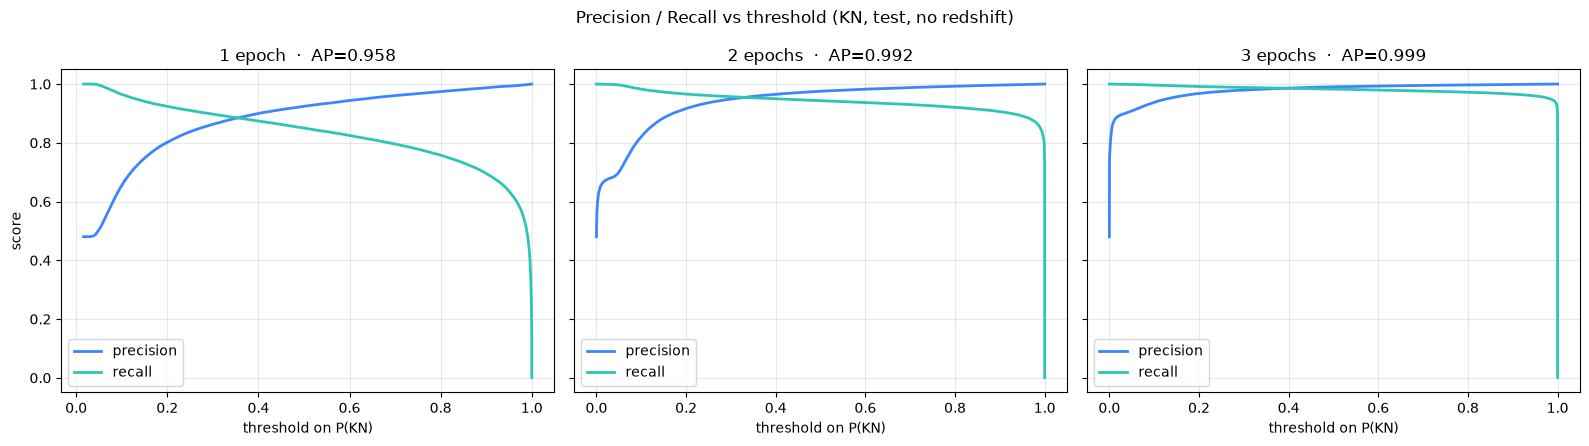

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, ep in zip(axes, EPOCHS):
    r = results[ep]
    precision, recall, thr = precision_recall_curve(r['y_true'], r['kn_prob'])
    ap = average_precision_score(r['y_true'], r['kn_prob'])
    ax.plot(thr, precision[:-1], label='precision', lw=2, color=C_PRECISION)
    ax.plot(thr, recall[:-1], label='recall', lw=2, color=C_RECALL)
    ax.set_title(f'{ep} epoch{"s" if ep > 1 else ""}  ·  AP={ap:.3f}')
    ax.set_xlabel('threshold on P(KN)'); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel('score')
fig.suptitle('Precision / Recall vs threshold (KN, test, no redshift)')
plt.tight_layout(); savefig(fig, '02_precision_recall.pdf'); plt.show()

### Por qué las curvas son tan planas: distribución de `P(KN)`

Las curvas son casi horizontales en el centro porque el modelo está **saturado**: casi todo
`P(KN)` cae pegado a 0 o a 1 y muy pocos objetos quedan en el medio, así que mover el umbral
entre ~0.05 y ~0.95 apenas cambia nada. El histograma (eje-y log) lo hace evidente por régimen.

saved plots/03_pkn_distribution.pdf


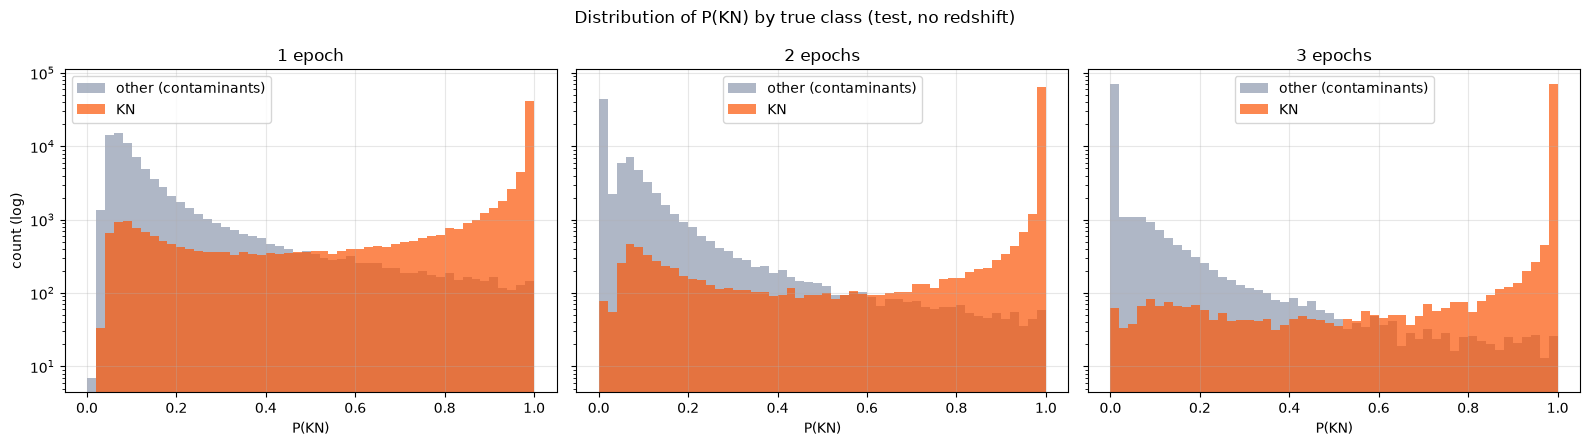

In [7]:
bins = np.linspace(0, 1, 51)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, ep in zip(axes, EPOCHS):
    r = results[ep]
    ax.hist(r['kn_prob'][r['y_true'] == 0], bins=bins, alpha=0.7, label='other (contaminants)', color=C_OTHER)
    ax.hist(r['kn_prob'][r['y_true'] == 1], bins=bins, alpha=0.7, label='KN', color=C_KN)
    ax.set_yscale('log')  # sin log, los extremos aplastan todo lo demás
    ax.set_title(f'{ep} epoch{"s" if ep > 1 else ""}')
    ax.set_xlabel('P(KN)'); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel('count (log)')
fig.suptitle('Distribution of P(KN) by true class (test, no redshift)')
plt.tight_layout(); savefig(fig, '03_pkn_distribution.pdf'); plt.show()

## 3. Matriz de confusión — por régimen de épocas (sin redshift)

Una CM por régimen {1, 2, 3 épocas}, umbral 0.5, normalizada por fila (% de cada clase verdadera)
y con el conteo de objetos entre paréntesis. Debajo, el `classification_report` por régimen.

saved plots/04_confusion_matrix.pdf


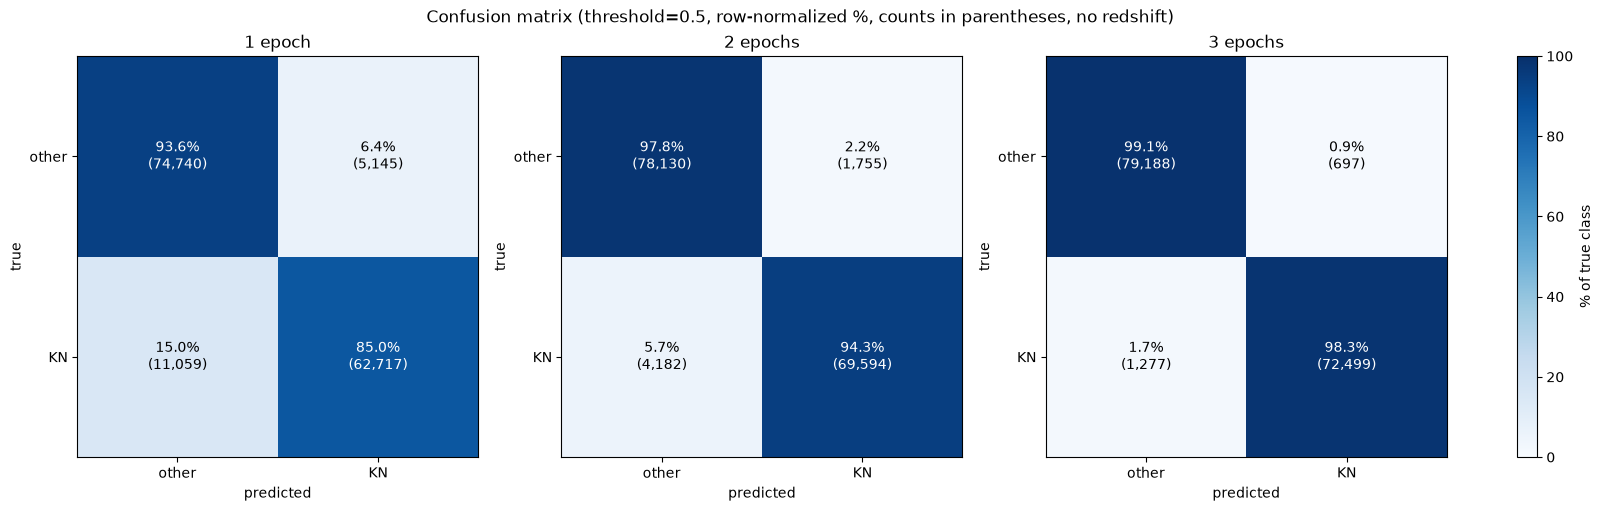

=== 1 epoch(s), no redshift ===
              precision    recall  f1-score   support

       other     0.8711    0.9356    0.9022     79885
          KN     0.9242    0.8501    0.8856     73776

    accuracy                         0.8945    153661
   macro avg     0.8976    0.8928    0.8939    153661
weighted avg     0.8966    0.8945    0.8942    153661

=== 2 epoch(s), no redshift ===
              precision    recall  f1-score   support

       other     0.9492    0.9780    0.9634     79885
          KN     0.9754    0.9433    0.9591     73776

    accuracy                         0.9614    153661
   macro avg     0.9623    0.9607    0.9612    153661
weighted avg     0.9618    0.9614    0.9613    153661

=== 3 epoch(s), no redshift ===
              precision    recall  f1-score   support

       other     0.9841    0.9913    0.9877     79885
          KN     0.9905    0.9827    0.9866     73776

    accuracy                         0.9872    153661
   macro avg     0.9873    0.987

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

THRESHOLD = 0.5
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for ax, ep in zip(axes, EPOCHS):
    r = results[ep]
    y_pred = (r['kn_prob'] >= THRESHOLD).astype(int)
    cm = confusion_matrix(r['y_true'], y_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100  # normalizada por fila (verdad) -> %
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(len(GROUP_ORDER)), GROUP_ORDER)
    ax.set_yticks(range(len(GROUP_ORDER)), GROUP_ORDER)
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    ax.set_title(f'{ep} epoch{"s" if ep > 1 else ""}')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f'{cm_pct[i, j]:.1f}%\n({cm[i, j]:,})', ha='center', va='center',
                    color='white' if cm_pct[i, j] > 50 else 'black')
fig.colorbar(im, ax=axes, fraction=0.046, label='% of true class')
fig.suptitle(f'Confusion matrix (threshold={THRESHOLD}, row-normalized %, counts in parentheses, no redshift)')
savefig(fig, '04_confusion_matrix.pdf'); plt.show()

for ep in EPOCHS:
    r = results[ep]
    y_pred = (r['kn_prob'] >= THRESHOLD).astype(int)
    print(f'=== {ep} epoch(s), no redshift ===')
    print(classification_report(r['y_true'], y_pred, target_names=GROUP_ORDER, digits=4))

## 4. Threshold = 0.2 → contaminantes por clase, por régimen (sin redshift)

Con umbral **0.2** (prioriza recall). Aquí se define el % de cada clase de contaminante que se
cuela como KN (FP / total de esa clase), así un valor se interpreta solo (p.ej. 10% de las SN Ic),
no como un conteo crudo, y se imprime el recall de KN por régimen. La figura se arma en la
sección 5, junto con el régimen con redshift.


In [ ]:
THRESHOLD_HR = 0.2

# orden de clases fijo (por nº total de contaminantes en test, desc) -> mismos ejes x en todos.
# el total por clase es el mismo en todos los regímenes (mismos objetos), lo calculamos una vez.
_contam = pd.Series(orig_label[results[3]['cid']][results[3]['y_true'] == 0]).value_counts()
CLASS_ORDER = list(_contam.index)
CLASS_TOTAL = _contam.reindex(CLASS_ORDER)


def fp_count_by_class(res, threshold):
    """Por época: nº de objetos de cada clase de contaminante que se predice como KN."""
    out = {}
    for ep, r in res.items():
        y_pred = (r['kn_prob'] >= threshold).astype(int)
        fp = (r['y_true'] == 0) & (y_pred == 1)
        out[ep] = pd.Series(orig_label[r['cid']][fp]).value_counts().reindex(CLASS_ORDER, fill_value=0)
    return out


def fp_percent_by_class(res, threshold):
    """Lo mismo, como % del total de la clase."""
    return {ep: counts / CLASS_TOTAL * 100 for ep, counts in fp_count_by_class(res, threshold).items()}


for ep in EPOCHS:
    r = results[ep]
    y_pred_hr = (r['kn_prob'] >= THRESHOLD_HR).astype(int)
    is_kn = r['y_true'] == 1
    fp = int(((r['y_true'] == 0) & (y_pred_hr == 1)).sum())
    print(f'{ep}ep (no redshift): KN recall={y_pred_hr[is_kn].mean():.4f}  |  contaminants as KN={fp}')


## 5. El mismo histograma, pero CON redshift

Idéntico a la sección 4, pero ahora alimentamos el redshift verdadero al modelo
(`force_redshift=True`). Como KN y contaminantes están casi disjuntos en z, se espera que
casi todos los contaminantes dejen de colarse — por eso el régimen sin z es la métrica honesta,
pero esto muestra cuánto "ayuda" (artificialmente) el redshift.

Los dos regímenes van en **una sola figura**: barras punteadas = sin redshift, barras rellenas =
con redshift.


In [ ]:
# loaders de test CON redshift (force_redshift=True) e inferencia por régimen
regime_loaders_z = {}
for ep in EPOCHS:
    ds = OpenUniverseWindowDataset(test_index, big=big, meta=meta, label_by_index=label_by_index,
                                   data_aug=False, force_epochs=ep, force_redshift=True)  # CON z
    regime_loaders_z[ep] = DataLoader(ds, batch_size=512, shuffle=False,
                                      collate_fn=collate_token_windows, num_workers=8)

results_z = {}
for ep, loader in regime_loaders_z.items():
    y_true, kn_prob, cid = [], [], []
    with torch.no_grad():
        for batch in loader:
            b = {k: v.to(device) for k, v in batch.items() if k in MODEL_INPUT_KEYS}
            probs = torch.softmax(model(b), dim=1)[:, 1]  # P(KN)
            kn_prob.append(probs.float().cpu().numpy())
            y_true.append(b['label'].cpu().numpy())
            cid.append(batch['cid'].cpu().numpy())
    results_z[ep] = {'y_true': np.concatenate(y_true),
                     'kn_prob': np.concatenate(kn_prob),
                     'cid': np.concatenate(cid)}
    r = results_z[ep]
    y_pred_hr = (r['kn_prob'] >= THRESHOLD_HR).astype(int)
    is_kn = r['y_true'] == 1
    fp = int(((r['y_true'] == 0) & (y_pred_hr == 1)).sum())
    print(f'{ep}ep (with redshift): KN recall={y_pred_hr[is_kn].mean():.4f}  |  contaminants as KN={fp}')


from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch

PRESENTATION_EPOCHS = 2  # el panel que va a la presentación


def draw_contaminant_panel(ax, no_z, with_z, label_fontsize):
    """Un rectángulo punteado por clase a la altura sin z, relleno desde el piso del eje hasta el
    valor con z, así los dos regímenes comparten el mismo contorno."""
    positions = np.arange(len(CLASS_ORDER))
    ax.bar(positions, with_z, width=0.8, color=C_CONTAM, alpha=0.9, linewidth=0)
    ax.bar(positions, no_z, width=0.8, facecolor='none', edgecolor=C_CONTAM, lw=1.8, linestyle='--')
    ax.set_xticks(positions, [f'{name}\n({CLASS_TOTAL[name]:,})' for name in CLASS_ORDER],
                  fontsize=label_fontsize)
    ax.set_yscale('log'); ax.set_ylim(0.6, 5e4); ax.grid(alpha=0.3, axis='y')
    # el conteo sin z va sobre el borde punteado y el con z justo bajo el tope del relleno, los dos
    # centrados -> no chocan ni cuando los dos regímenes coinciden.
    for i, v in enumerate(no_z):
        if v > 0:
            ax.text(i, v * 1.15, f'{v:,}', ha='center', va='bottom', fontsize=label_fontsize, color=C_CONTAM)
    for i, v in enumerate(with_z):
        if v >= 10:  # un relleno de menos de una década no alcanza para meter la etiqueta adentro
            ax.text(i, v / 1.15, f'{v:,}', ha='center', va='top', fontsize=label_fontsize, color='white')
        elif v > 0:
            ax.text(i, v * 1.15, f'{v:,}', ha='center', va='bottom', fontsize=label_fontsize, color='black')


def contaminant_legend_handles():
    return [Patch(facecolor='none', edgecolor=C_CONTAM, linestyle='--', lw=1.8, label='no redshift'),
            Patch(facecolor=C_CONTAM, alpha=0.9, label='with redshift')]


count_no_z = fp_count_by_class(results, THRESHOLD_HR)
count_z = fp_count_by_class(results_z, THRESHOLD_HR)

pdf_path = os.path.join(PLOTS_DIR, '05_contaminants_redshift_comparison.pdf')
with PdfPages(pdf_path) as pdf_pages:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
    for ax, ep in zip(axes, EPOCHS):
        draw_contaminant_panel(ax, count_no_z[ep].values, count_z[ep].values, 8)
        ax.set_title(f'{ep} epoch{"s" if ep > 1 else ""}', fontsize=14)
    axes[0].set_ylabel('contaminants predicted as KN (log)', fontsize=13)
    axes[1].set_xlabel('true class (total in test)', fontsize=13)
    axes[0].legend(handles=contaminant_legend_handles(), fontsize=11, loc='upper right')
    fig.suptitle(f'Contaminants leaking as KN by true class  (threshold={THRESHOLD_HR})', fontsize=16)
    plt.tight_layout(); pdf_pages.savefig(fig, bbox_inches='tight'); plt.show()

    # segunda página: el panel de 2 épocas solo, grande -> la figura de la presentación.
    fig, ax = plt.subplots(figsize=(12, 7))
    draw_contaminant_panel(ax, count_no_z[PRESENTATION_EPOCHS].values, count_z[PRESENTATION_EPOCHS].values, 13)
    ax.set_ylabel('contaminants predicted as KN (log)', fontsize=17)
    ax.set_xlabel('true class (total in test)', fontsize=17)
    ax.tick_params(axis='y', labelsize=14)
    ax.legend(handles=contaminant_legend_handles(), fontsize=15, loc='upper right')
    ax.set_title(f'Contaminants leaking as KN by true class\n'
                 f'({PRESENTATION_EPOCHS} epochs, threshold={THRESHOLD_HR})', fontsize=19)
    plt.tight_layout(); pdf_pages.savefig(fig, bbox_inches='tight'); plt.show()
print('saved', pdf_path)
